<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/07_Visualization/Chipotle/Exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv).

### Step 3. Assign it to a variable called chipo.

In [65]:
chipo = pd.read_csv('https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv', sep='\t')

In [66]:
chipo.nunique()

,0
order_id,1834
quantity,9
item_name,50
choice_description,1043
item_price,78


### Step 4. See the first 10 entries

In [67]:
chipo.head(5)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


### Step 5. Create a histogram of the top 5 items bought

<Axes: ylabel='Frequency'>

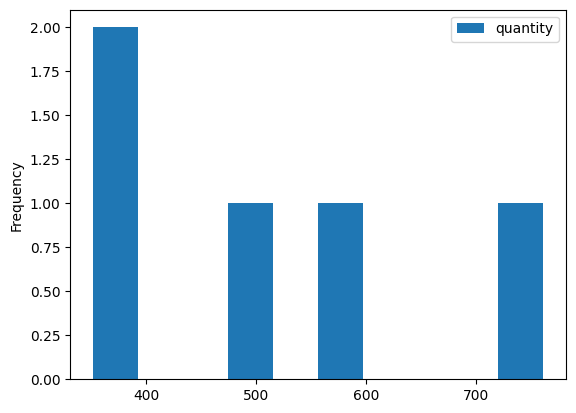

In [68]:
new_chipo = chipo.groupby('item_name')['quantity'].sum().sort_values(ascending=False).head(5).reset_index()
new_chipo.plot(kind='hist')


### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

In [69]:
chipo.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


In [70]:
chipo.item_price = [float(value[1:-1]) for value in chipo.item_price] # strip the dollar sign and trailing space

In [71]:
chipo['item_price'].astype('float')

,item_price
0,2.39
1,3.39
2,3.39
3,2.39
4,16.98
...,...
4617,11.75
4618,11.75
4619,11.25
4620,8.75


In [72]:
chipo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            4622 non-null   int64  
 1   quantity            4622 non-null   int64  
 2   item_name           4622 non-null   object 
 3   choice_description  3376 non-null   object 
 4   item_price          4622 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 180.7+ KB


In [73]:
chipo.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39
1,1,1,Izze,[Clementine],3.39
2,1,1,Nantucket Nectar,[Apple],3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98


<Axes: xlabel='item_price', ylabel='quantity'>

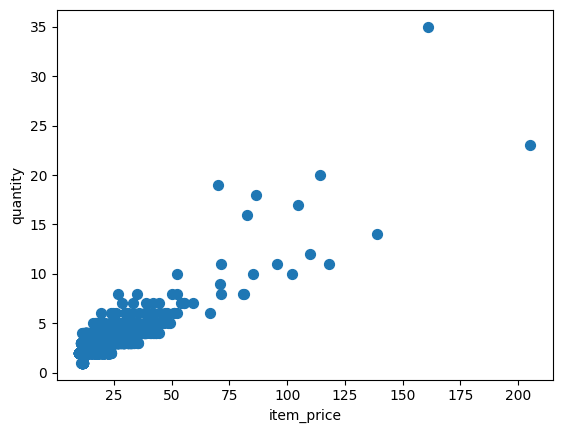

In [83]:
chipo_new = chipo.groupby('order_id').sum(numeric_only=True)
chipo_new.plot(x='item_price', y='quantity', kind='scatter', s=50)

### Step 7. BONUS: Create a question and a graph to answer your own question.

My question: top 5 products and how much ordered

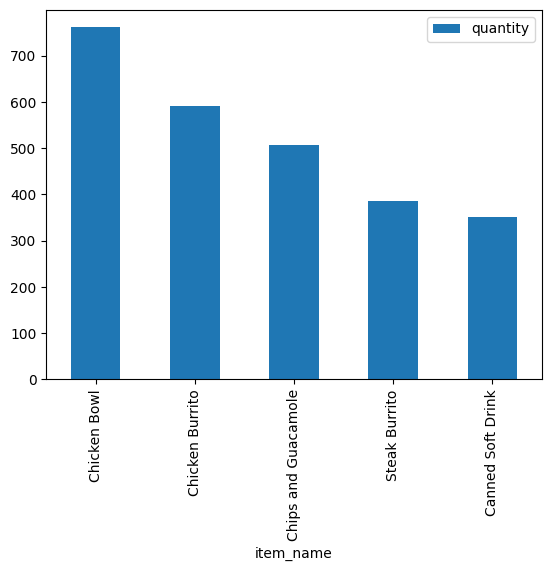

In [75]:
new_chipo = chipo.groupby('item_name')['quantity'].sum() \
                 .sort_values(ascending=False) \
                 .head(5) \
                 .reset_index()

ax = new_chipo.plot(
    x='item_name',
    y='quantity',
    kind='bar',
    colormap='tab10'
)
plt.xticks(rotation=90)
plt.show()